In [1]:
import os
from pathlib import Path

from tqdm import tqdm

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import shap
from boruta import BorutaPy
import neurokit2 as nk

from helper_code import *
import util

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-23 16:39:05.925965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737646745.949386   41388 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737646745.956823   41388 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-23 16:39:05.984960: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in pe

In [2]:
%load_ext autoreload

%autoreload 2

# Control figure size
%matplotlib inline
figsize=(14, 4)

In [8]:
train_data_folder = Path("code15_wfdb")
holdout_data_folder = Path("holdout_data")

train_records = find_records(train_data_folder.absolute().__str__())
holdout_records = find_records(holdout_data_folder.absolute().__str__())

all_records = train_records + holdout_records

---

For each record inside both the training and holdout data do:
1. extract signals and apply an aggregation function to each signal (mean and std)
2. extract the label of each signal
3. find the attributes inside the exams csv for that specific exam id
4. handle the death and timey NaN components
5. create a new feature as the difference between age and predicted age
6. onehot encoding of gender
7. binning of age?
8. drop useless columns

In [3]:
exams = pd.read_csv("code15_hdf5/exams.csv")

In [4]:
exams

,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345774,1123951,33,True,35.893005,False,False,False,False,False,False,770553,False,2.189039,True,exams_part2.hdf5
345775,954704,73,False,68.169136,False,False,False,False,False,False,1044781,False,2.520546,False,exams_part2.hdf5
345776,589697,75,False,78.080810,False,False,False,False,False,False,1020589,False,3.304107,False,exams_part2.hdf5
345777,2780563,44,False,73.120636,False,False,False,False,False,False,178,False,7.339720,False,exams_part2.hdf5


In [5]:
data = {
    "exam_id": [],
    "age": [],
    "nn_predicted_age": [],
    "sex": [],
    "mean_DI": [],
    "std_DI": [],
    "mean_DII": [],
    "std_DII": [],
    "mean_DIII": [],
    "std_DIII": [],
    "mean_AVR": [],
    "std_AVR": [],
    "mean_AVL": [],
    "std_AVL": [],
    "mean_AVF": [],
    "std_AVF": [],
    "mean_V1": [],
    "std_V1": [],
    "mean_V2": [],
    "std_V2": [],
    "mean_V3": [],
    "std_V3": [],
    "mean_V4": [],
    "std_V4": [],
    "mean_V5": [],
    "std_V5": [],
    "mean_V6": [],
    "std_V6": [],
    "1dAVb": [],
    "RBBB": [],
    "LBBB": [],
    "SB": [],
    "ST": [],
    "AF": [],
    "patient_id": [],
    "death": [],
    "normal_ecg": [],
    "label": []
}

for record in tqdm(all_records):
    # Convert to integer
    #record = int(record)

    # Extract the label
    try:
        str_record = str(train_data_folder.absolute()) + "/" + record
        label = load_label(str_record)
    except:
        str_record = str(holdout_data_folder.absolute()) + "/" + record
        label = load_label(str_record)

    # Extract the signal
    signal, fields = load_signals(str_record)
    
    # Aggregate the signals
    mean_signal = np.mean(signal, axis=0)
    std_signal = np.std(signal, axis=0)

    # Get the header
    header = load_header(str_record)

    # Get the age
    age = get_age(header)
    sex = get_sex(header) 

    # Get the attributes from the exam
    attributes = exams[exams.exam_id == int(record)]

    death = attributes['death'].values[0]
    if death == np.nan:
        death = -1
    elif death == True:
        death = 1
    else:
        death = 0

    # Append the data
    data["exam_id"].append(int(record))
    data["age"].append(int(age))
    data["nn_predicted_age"].append(attributes['nn_predicted_age'].values[0])
    data["sex"].append(sex)
    data["mean_DI"].append(mean_signal[0])
    data["std_DI"].append(std_signal[0])
    data["mean_DII"].append(mean_signal[1])
    data["std_DII"].append(std_signal[1])
    data["mean_DIII"].append(mean_signal[2])
    data["std_DIII"].append(std_signal[2])
    data["mean_AVR"].append(mean_signal[3])
    data["std_AVR"].append(std_signal[3])
    data["mean_AVL"].append(mean_signal[4])
    data["std_AVL"].append(std_signal[4])
    data["mean_AVF"].append(mean_signal[5])
    data["std_AVF"].append(std_signal[5])
    data["mean_V1"].append(mean_signal[6])
    data["std_V1"].append(std_signal[6])
    data["mean_V2"].append(mean_signal[7])
    data["std_V2"].append(std_signal[7])
    data["mean_V3"].append(mean_signal[8])
    data["std_V3"].append(std_signal[8])
    data["mean_V4"].append(mean_signal[9])
    data["std_V4"].append(std_signal[9])
    data["mean_V5"].append(mean_signal[10])
    data["std_V5"].append(std_signal[10])
    data["mean_V6"].append(mean_signal[11])
    data["std_V6"].append(std_signal[11])
    data["1dAVb"].append(attributes['1dAVb'].values[0])
    data["RBBB"].append(attributes['RBBB'].values[0])
    data["LBBB"].append(attributes['LBBB'].values[0])
    data["SB"].append(attributes['SB'].values[0])
    data["ST"].append(attributes['ST'].values[0])
    data["AF"].append(attributes['AF'].values[0])
    data["patient_id"].append(attributes['patient_id'].values[0])
    data["death"].append(death)
    data["normal_ecg"].append(attributes['normal_ecg'].values[0])
    data["label"].append(label)

100%|██████████| 39798/39798 [03:55<00:00, 169.06it/s]


In [6]:
df = pd.DataFrame(data)
df.to_csv("data/data.csv", index=False, encoding='utf-8')

---

In [24]:
example_record = str(train_data_folder.absolute()) + "/" + train_records[0]
header = load_header(example_record)
signals, fields = load_signals(example_record)
frequency = get_sampling_frequency(header)

In [144]:
label = get_label(header)
label

0

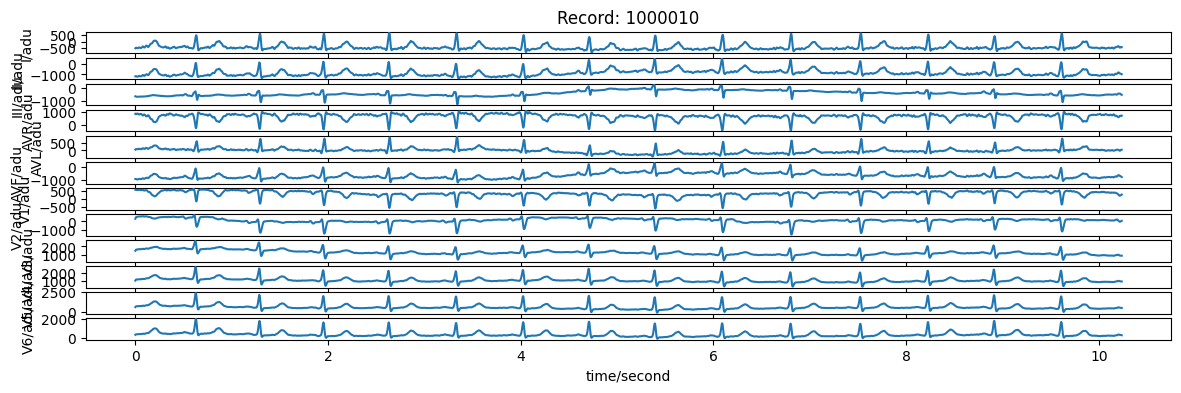

In [20]:
wfdb.plot_wfdb(record=wfdb.rdrecord(example_record, physical=False), figsize=figsize)

In [100]:
fields['sig_name']

['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [101]:
processed_signals, info = nk.ecg_process(ecg_signal=signals[:, 1], sampling_rate=frequency)

P wave duration:
1. take when P is offset
2. take when P is onset
3. take the difference of their indices
4. divide by the sampling rate

Output: P wave duration in seconds (since Hz is seconds^-1)

In [120]:
p_wave_durations = (processed_signals[processed_signals['ECG_P_Offsets'] == 1].index - processed_signals[processed_signals['ECG_P_Onsets'] == 1].index) / frequency

In [122]:
np.mean(p_wave_durations), np.std(p_wave_durations)

(np.float64(0.09196428571428572), np.float64(0.016907800699375298))

PR interval:
1. take when P is onset
2. take when Q is onset
3. take the difference of their indices
4. divide by the sampling rate

Output: PR interval in seconds (since Hz is seconds^-1)

In [140]:
pr_interval = (processed_signals[processed_signals['ECG_Q_Peaks'] == 1].index - processed_signals[processed_signals['ECG_P_Onsets'] == 1].iloc[:-1].index) / frequency * 1000

In [141]:
np.mean(pr_interval), np.std(pr_interval)

(np.float64(103.65384615384616), np.float64(12.271581641187552))

In [137]:
nk.ecg_analyze(processed_signals, sampling_rate=frequency)

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/neurokit2/complexity/optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/neurokit2/complexity/optim_complexity_k.py:135: RuntimeWarning: inva

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,86.873183,[[690.9615384615385]],[[17.516018309989786]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[13.030413142593241]],...,[[-inf]],[[3.5465935642949393]],[[1.2677056104195426]],[[nan]],[[nan]],[[nan]],[[2.10757561876307]],[[nan]],[[1.4804939670987842]],[[1.4232460454388816]]


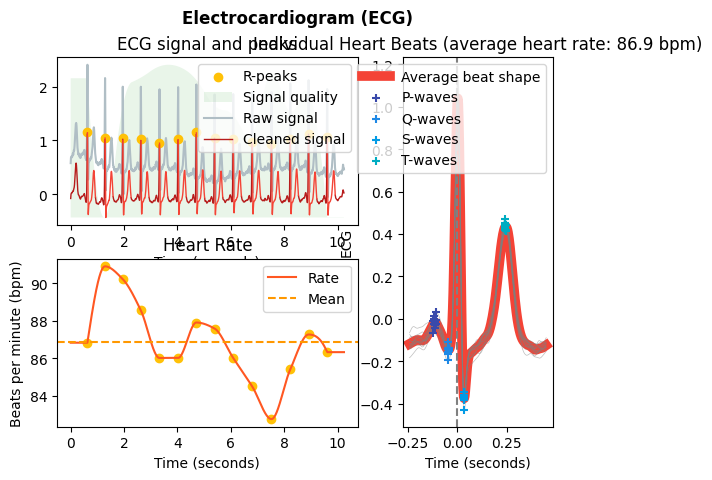

In [55]:
nk.ecg_plot(processed_signals, info)

In [3]:
df = pd.read_csv("data/data.csv", encoding='utf-8')

In [4]:
df.head()

,exam_id,age,nn_predicted_age,sex,mean_DI,std_DI,mean_DII,std_DII,mean_DIII,std_DIII,...,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,normal_ecg,label
0,1000010,40,37.822990,Female,-0.450692,0.222797,-0.864404,0.273517,-0.413709,0.194939,...,False,False,False,False,False,False,415630,0,True,0
1,1000078,56,44.491043,Male,-0.313750,0.347462,-1.692581,0.560666,-1.378823,0.339585,...,False,False,False,False,False,False,695177,0,False,0
2,1000087,72,75.249695,Male,1.079969,0.468575,2.401406,0.958448,1.321447,0.572557,...,False,False,False,False,False,False,1161144,0,False,0
3,1000182,33,28.969059,Female,0.002325,0.220697,0.003436,0.301733,0.001109,0.106127,...,False,False,False,False,False,False,966826,0,True,0
4,1000263,54,79.824660,Female,0.000717,0.176115,-0.002417,0.253241,-0.003094,0.329076,...,False,True,False,False,False,False,1509478,0,False,0


In [5]:
df['sex'] = df['sex'].apply(lambda x: 1 if x == 'M' else 0)
df['1dAVb'] = df['1dAVb'].apply(lambda x: 1 if x == True else 0)
df['RBBB'] = df['RBBB'].apply(lambda x: 1 if x == True else 0)
df['LBBB'] = df['LBBB'].apply(lambda x: 1 if x == True else 0)
df['SB'] = df['SB'].apply(lambda x: 1 if x == True else 0)
df['ST'] = df['ST'].apply(lambda x: 1 if x == True else 0)
df['AF'] = df['AF'].apply(lambda x: 1 if x == True else 0)
df['normal_ecg'] = df['normal_ecg'].apply(lambda x: 1 if x == True else 0)

In [6]:
df['nn_predicted_age'] = df['age'] - df['nn_predicted_age']
df.rename(columns={'nn_predicted_age': 'heart_age_discrepancy'}, inplace=True)

In [7]:
df.describe()

,exam_id,age,heart_age_discrepancy,sex,mean_DI,std_DI,mean_DII,std_DII,mean_DIII,std_DIII,...,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,normal_ecg,label
count,3.979800e+04,39798.000000,39798.000000,39798.0,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,...,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,39798.000000,3.979800e+04,39798.000000,39798.000000,39798.000000
mean,1.460541e+06,52.970024,-0.949555,0.0,0.027265,0.349579,-0.085853,0.416263,-0.113116,0.365916,...,0.017111,0.026961,0.017011,0.016383,0.021710,0.020277,7.933730e+05,0.026534,0.383813,0.020579
std,1.158977e+06,19.726332,11.004051,0.0,0.872341,0.496514,1.631345,0.507951,1.627405,0.549678,...,0.129688,0.161972,0.129313,0.126944,0.145736,0.140949,5.519819e+05,0.160719,0.486319,0.141972
min,1.400000e+01,17.000000,-70.459526,0.0,-12.776328,0.000000,-15.080458,0.000000,-15.270543,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+00,0.000000,0.000000,0.000000
25%,5.679458e+05,36.000000,-7.531614,0.0,-0.004926,0.195360,-0.117893,0.219191,-0.151299,0.146428,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.530472e+05,0.000000,0.000000,0.000000
50%,1.132691e+06,54.000000,-0.920599,0.0,0.001537,0.260882,0.000403,0.302144,-0.000923,0.227749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.589030e+05,0.000000,0.000000,0.000000
75%,2.658224e+06,70.000000,5.939183,0.0,0.009679,0.358157,0.005815,0.432203,0.003755,0.380995,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.283076e+06,0.000000,1.000000,0.000000
max,4.416554e+06,91.000000,68.739881,0.0,16.219297,13.239260,18.044898,12.039916,17.027142,13.331735,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.773653e+06,1.000000,1.000000,1.000000


In [8]:
factor_cols = ['patient_id','exam_id']
num_cols = [c for c in df.columns[:-1] if df[c].nunique() > 2 and c not in factor_cols]
cat_cols = [c for c in df.columns[:-1] if df[c].nunique() == 2 and c not in factor_cols]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

Numeric: ['age', 'heart_age_discrepancy', 'mean_DI', 'std_DI', 'mean_DII', 'std_DII', 'mean_DIII', 'std_DIII', 'mean_AVR', 'std_AVR', 'mean_AVL', 'std_AVL', 'mean_AVF', 'std_AVF', 'mean_V1', 'std_V1', 'mean_V2', 'std_V2', 'mean_V3', 'std_V3', 'mean_V4', 'std_V4', 'mean_V5', 'std_V5', 'mean_V6', 'std_V6']
Total: 26
Categorical: ['1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF', 'death', 'normal_ecg']
Total: 8


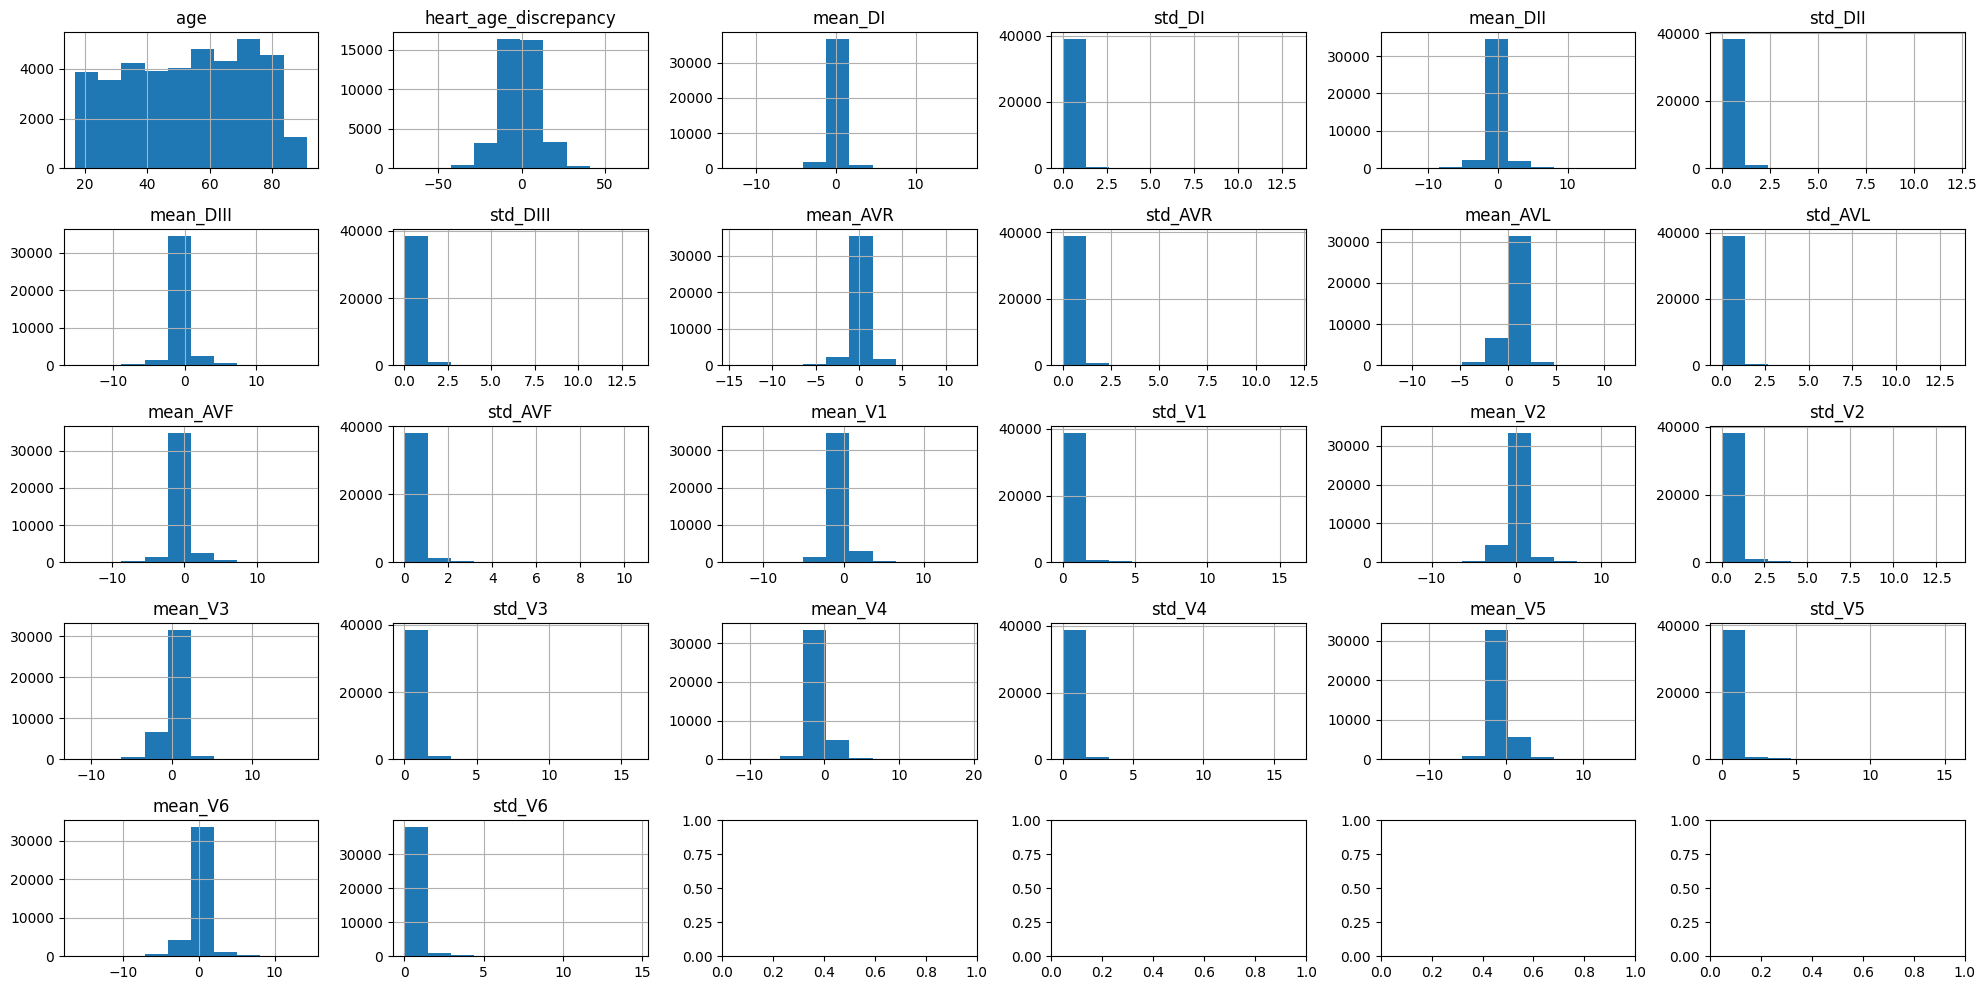

In [9]:
_, axes = plt.subplots(nrows=5, ncols=int(np.ceil(len(num_cols)//4)), figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    df.hist(cname, ax=ax)
plt.tight_layout()
plt.show()

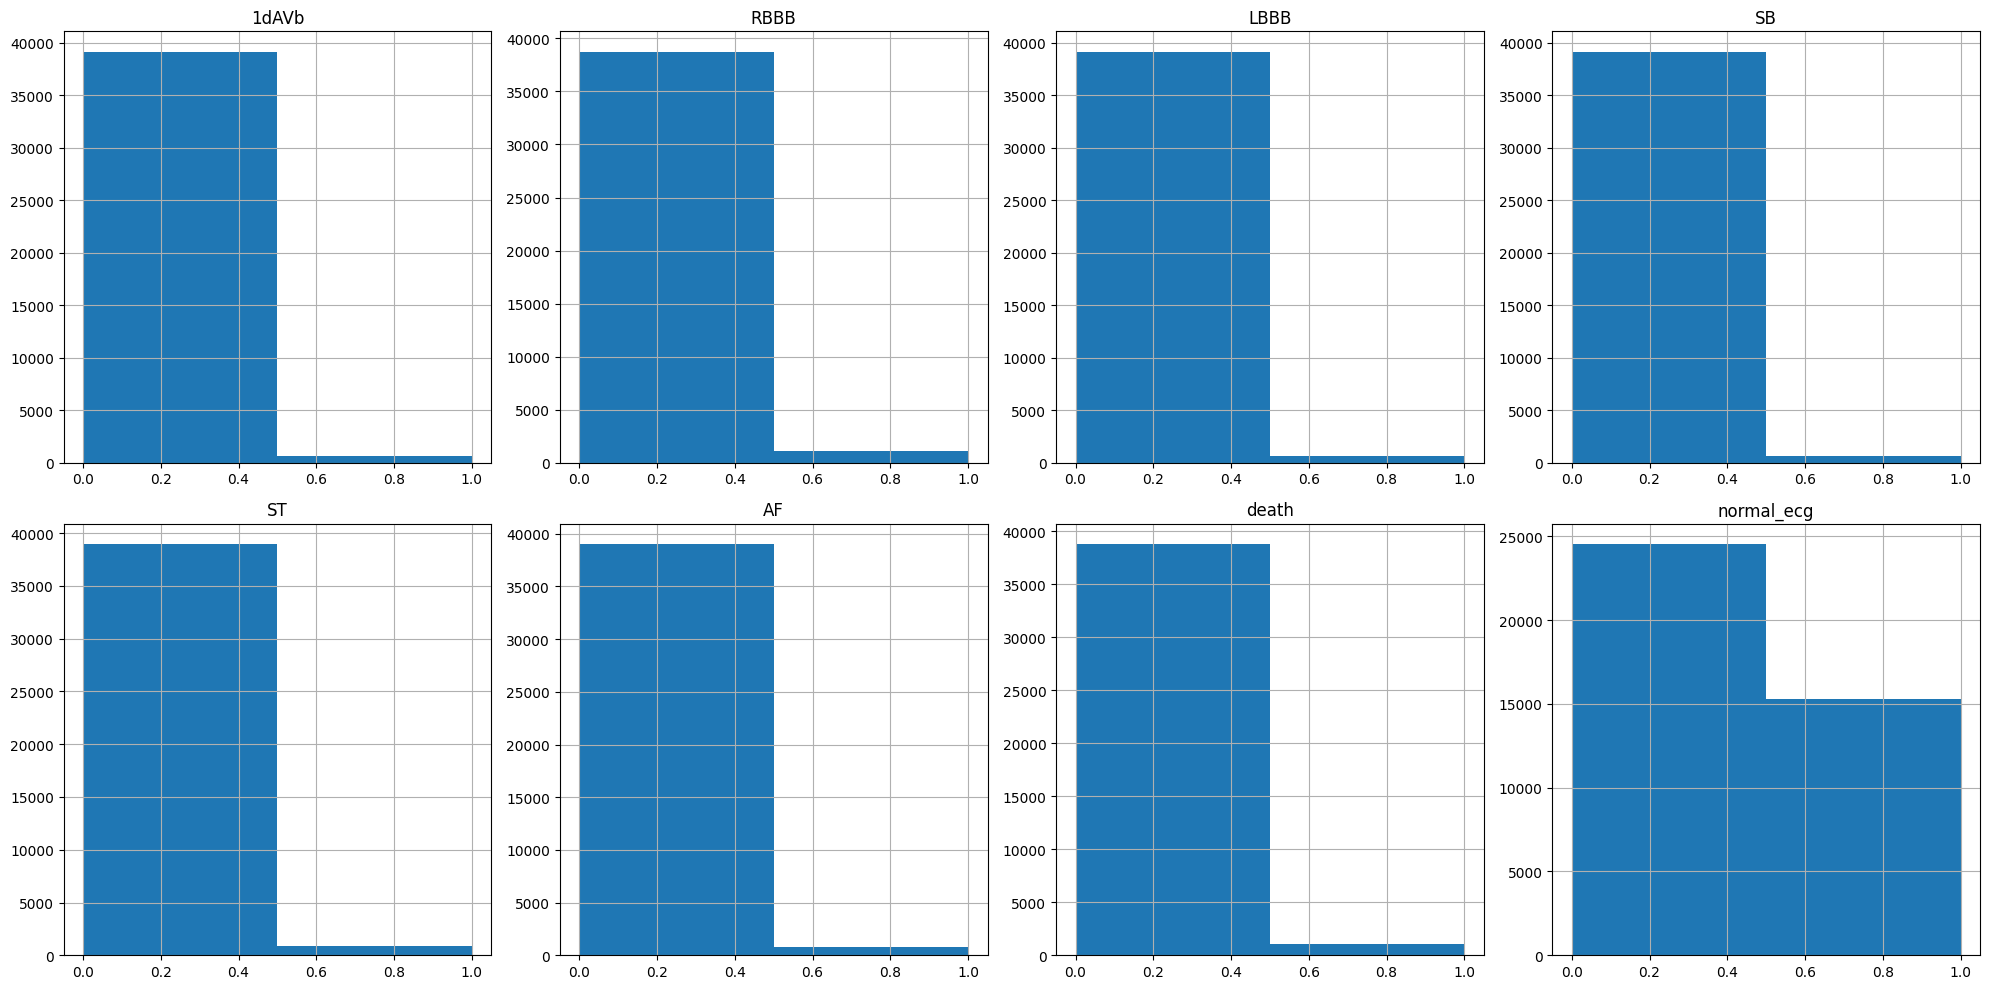

In [10]:
_, axes = plt.subplots(nrows=2, ncols=int(np.ceil(len(cat_cols)//2)), figsize=(20, 10))
for ax, cname in zip(axes.ravel(), cat_cols):
    df.hist(cname, ax=ax, bins=2)
plt.tight_layout()

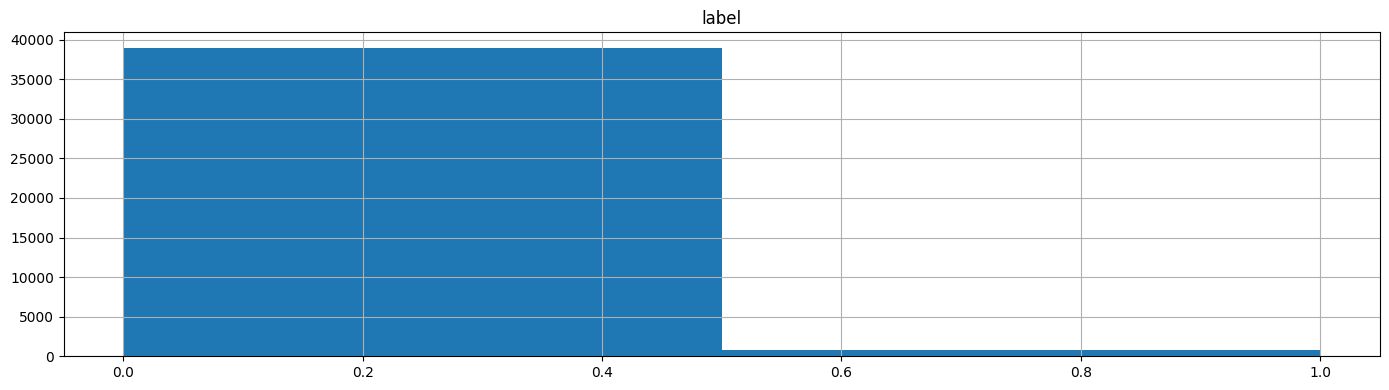

In [11]:
df.hist('label', bins=2, figsize=figsize)
plt.tight_layout()


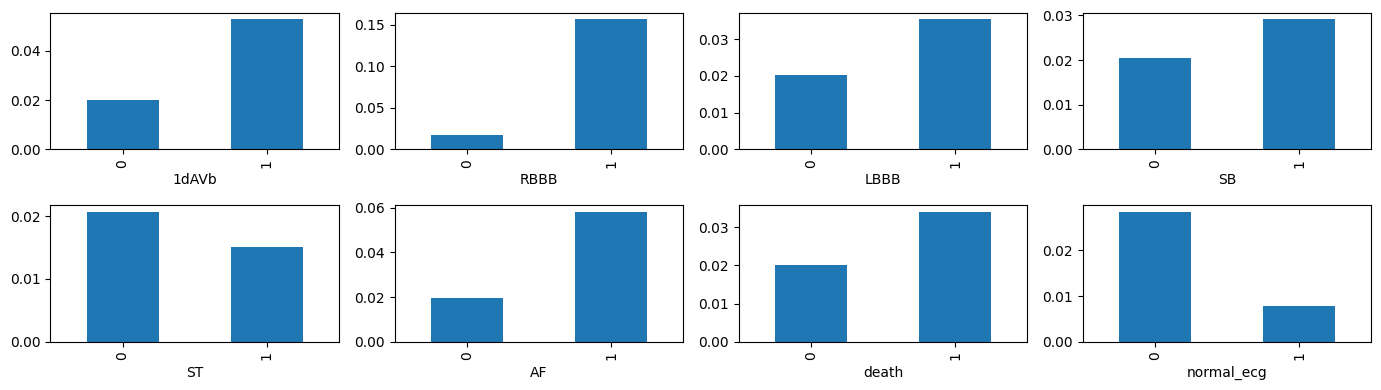

In [12]:
_, axes = plt.subplots(nrows=2, ncols=int(np.ceil(len(cat_cols)//2)), figsize=figsize)
for ax, cname in zip(axes.ravel(), cat_cols):
    df.groupby(cname)['label'].mean().plot.bar(ax=ax)
plt.tight_layout()

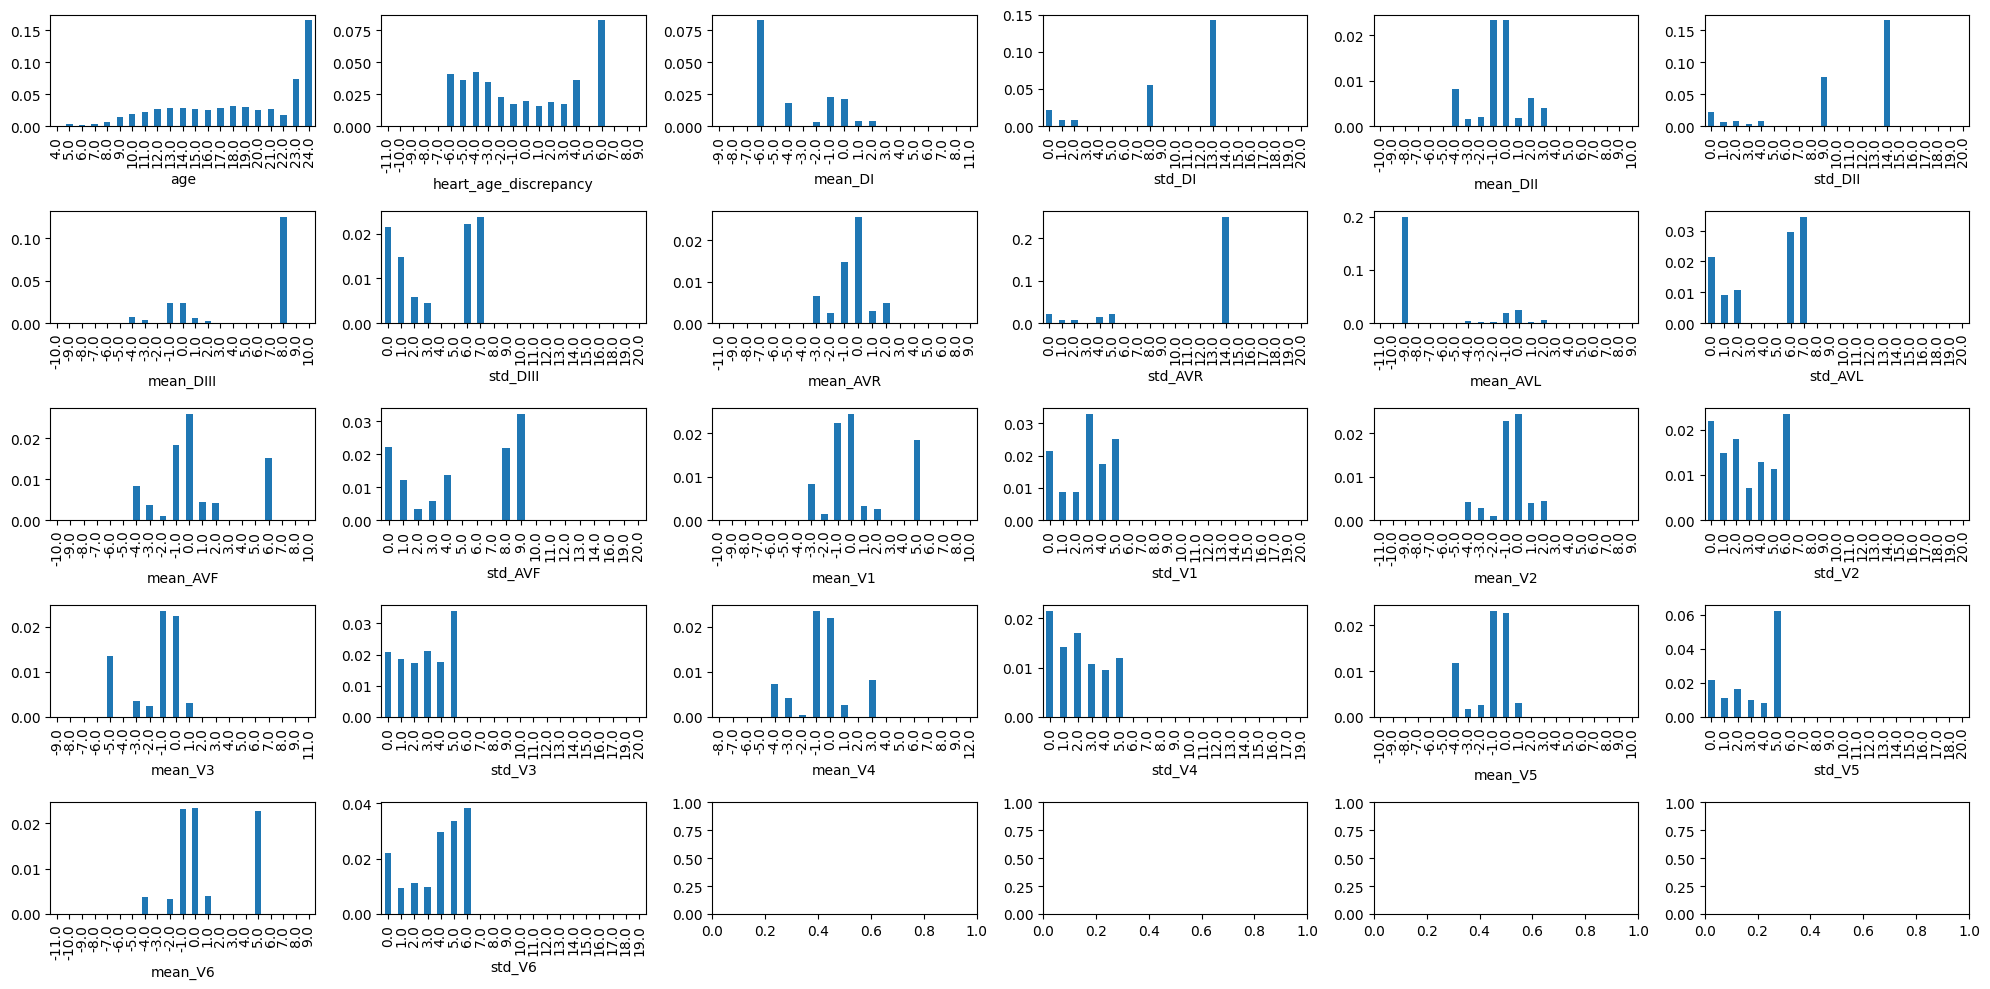

In [13]:
_, axes = plt.subplots(nrows=5, ncols=int(np.ceil(len(num_cols)//4)), figsize=(20,10))
for ax, cname in zip(axes.ravel(), num_cols):
    bin_size = (df[cname].max() - df[cname].min()) / 20
    df['label'].groupby(df[cname] // bin_size).mean().plot.bar(ax=ax)
plt.tight_layout()

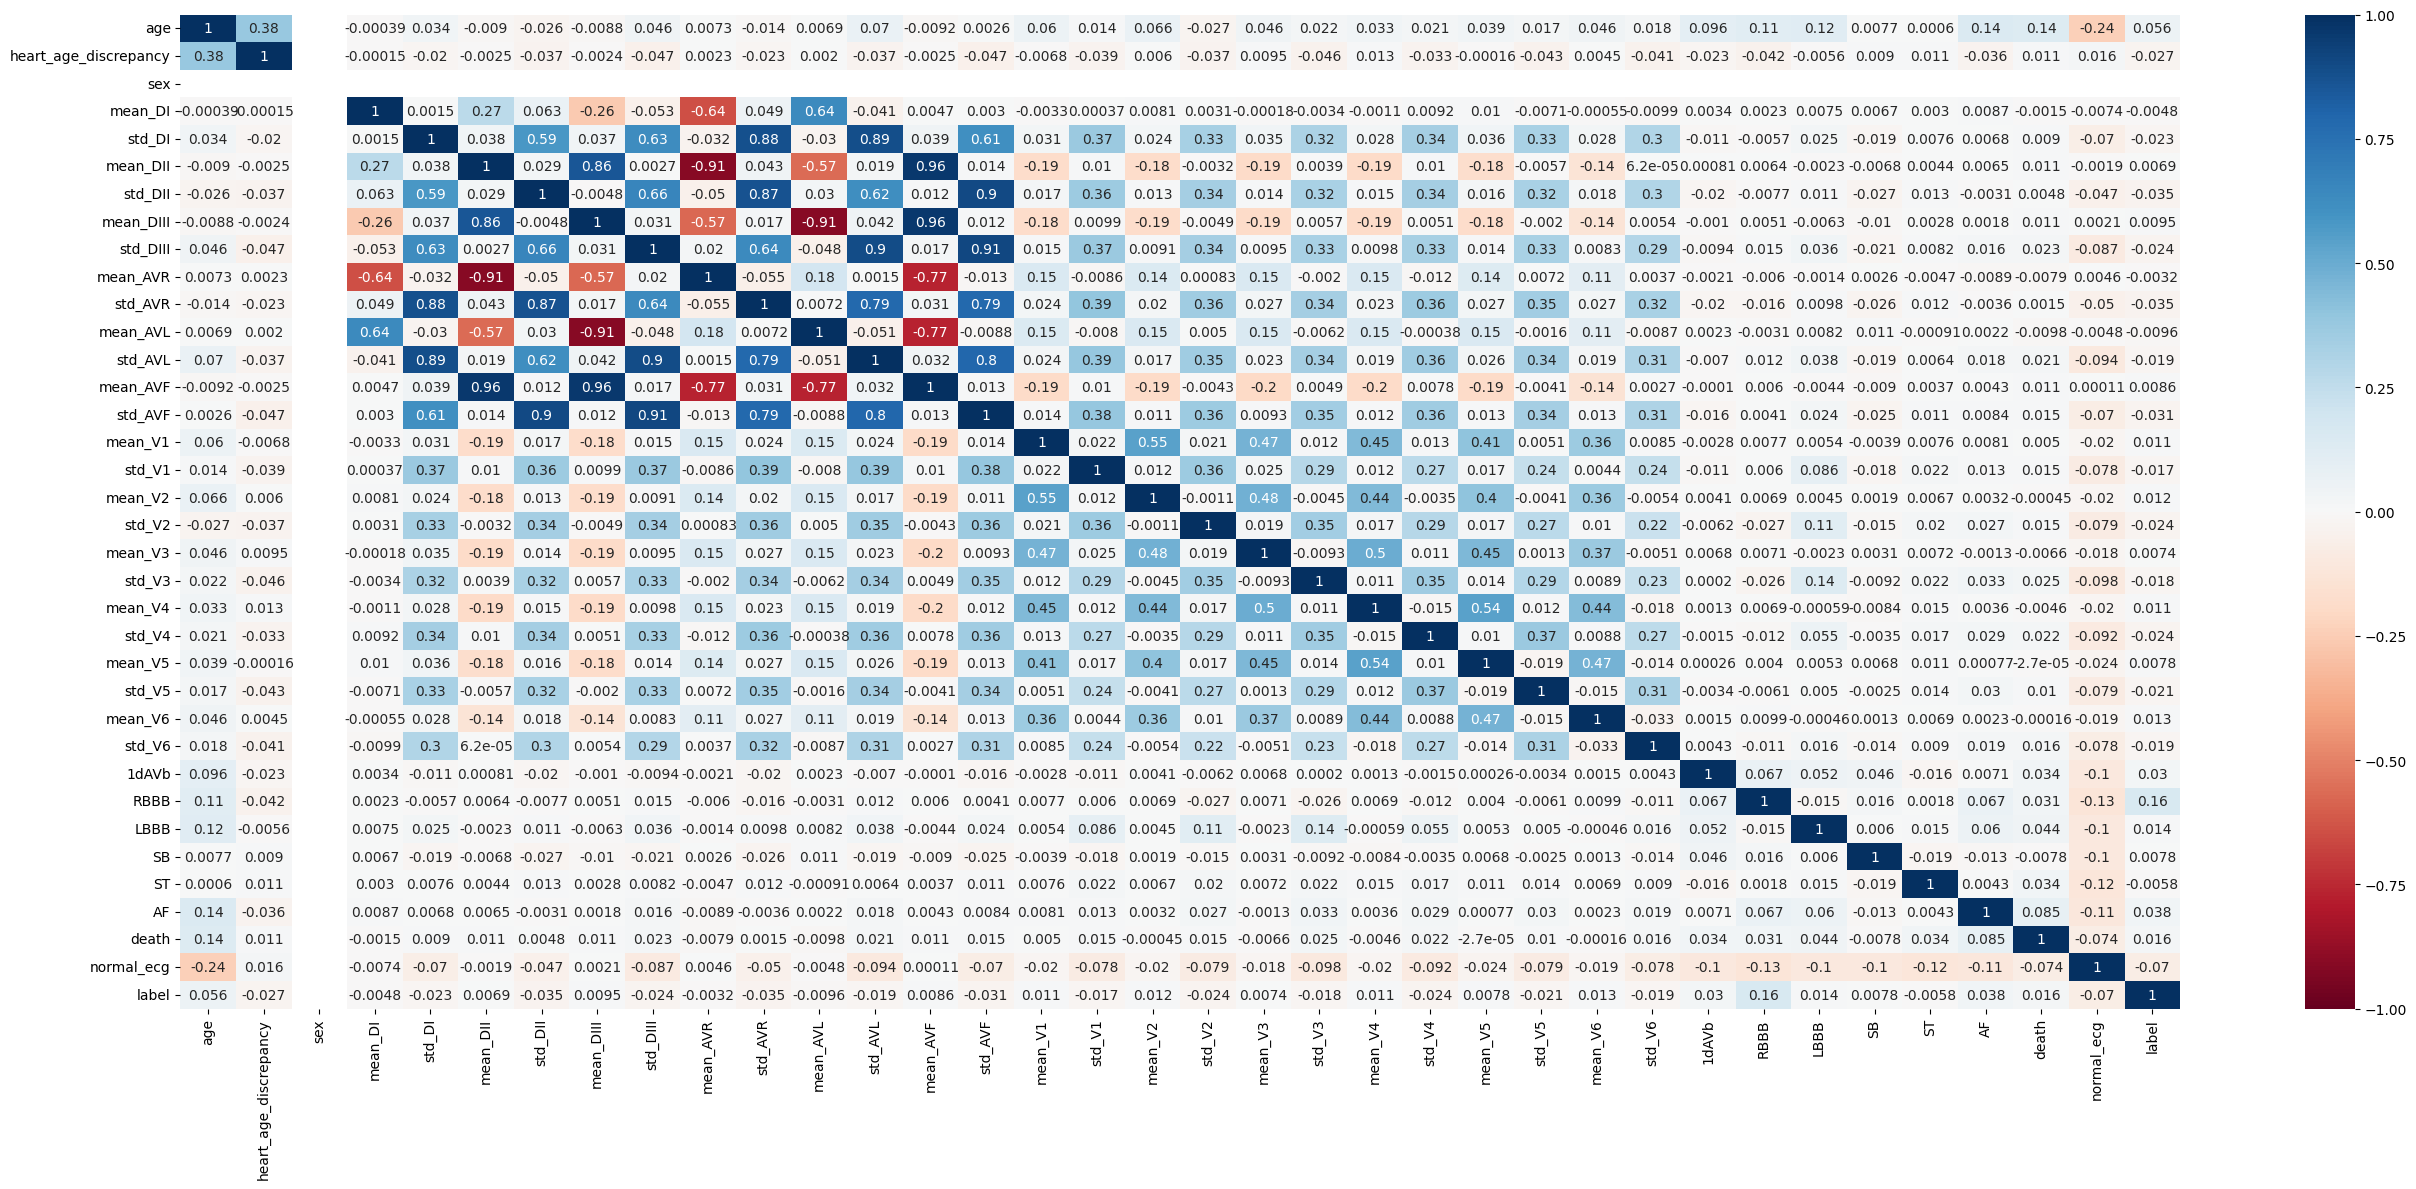

In [14]:
plt.figure(figsize=(27,12))
sn.heatmap(df.drop(columns=factor_cols).corr(method='pearson', numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

In [64]:
from sklearn.preprocessing import MinMaxScaler


clean_df = df.drop(columns=factor_cols + ['RBBB'])

X, y = clean_df.drop(columns='label'), clean_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [73]:
base_est = LogisticRegression(penalty='l2', solver='lbfgs')
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

In [74]:



lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.74 (cross-validation), 0.70 (test)


<Axes: >

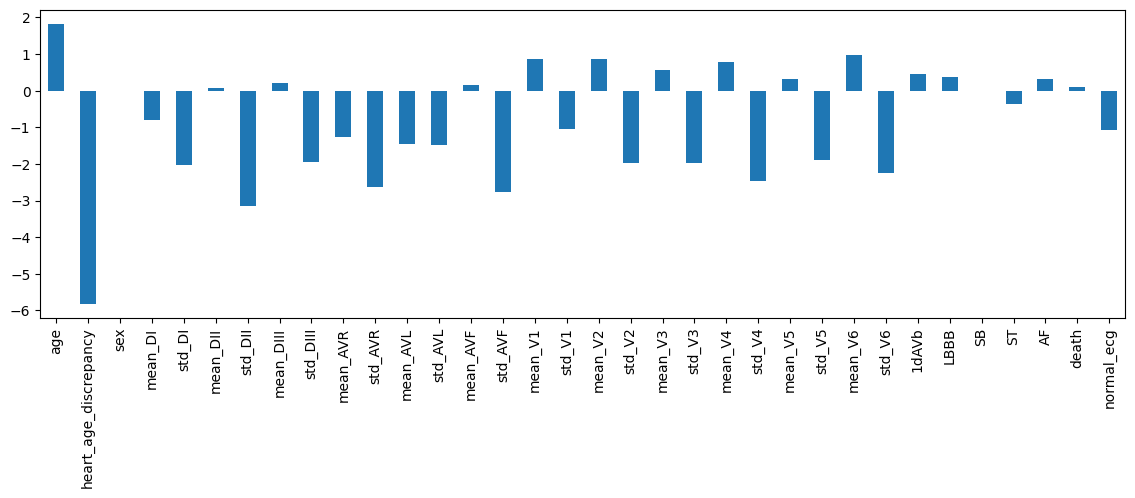

In [75]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
lr_coefs.plot(kind='bar', figsize=figsize)

In [31]:
import xgboost
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

<Axes: >

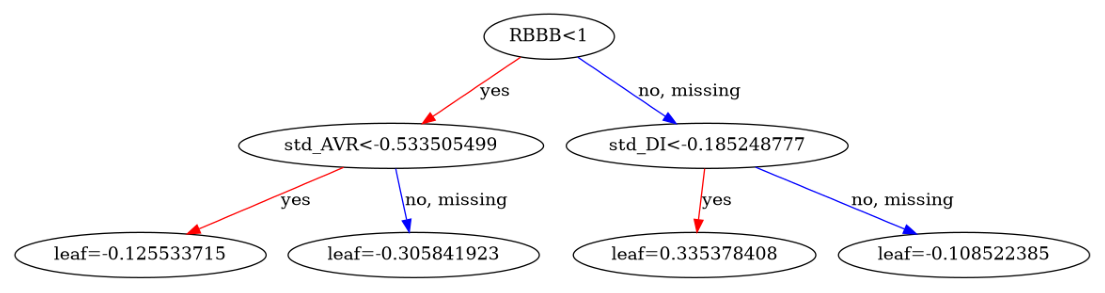

In [32]:
plt.figure(figsize=figsize)
xgboost.plot_tree(xbm, ax=plt.gca(), num_trees=0)

In [35]:
xbm_score_cv, xbm_score_test = gscv.best_score_, roc_auc_score(y_test, xbm.predict(X_test))
print(f'AUC score for {xbm_params}: {xbm_score_cv:.2f} (cross-val.), {xbm_score_test:.2f} (test)')

AUC score for {'max_depth': 2, 'n_estimators': 20, 'reg_lambda': np.float64(0.0)}: 0.98 (cross-val.), 0.50 (test)


<Axes: >

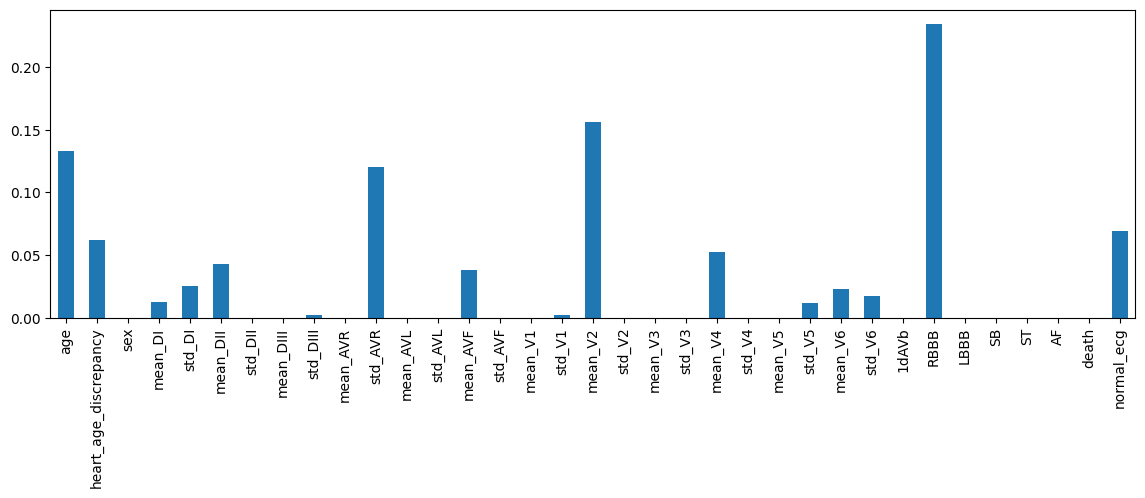

In [36]:
xbm_imp = pd.Series(index=X.columns, data=xbm.feature_importances_)
xbm_imp.plot(kind='bar', figsize=figsize)

/tmp/ipykernel_47219/3116684602.py:4: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


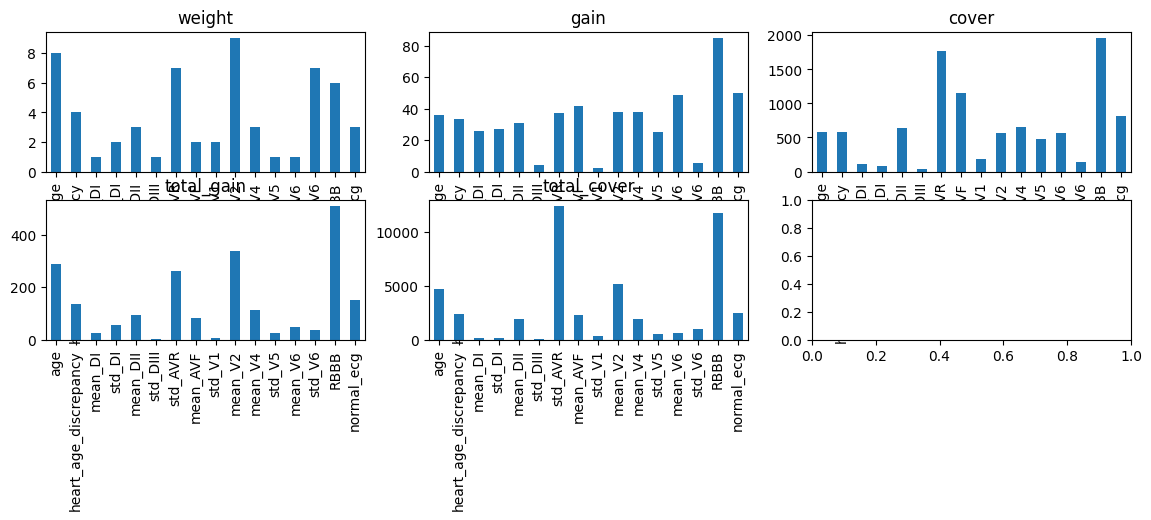

In [37]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)
for ax, imp_type in zip(axes.ravel(), ['weight', 'gain', 'cover', 'total_gain', 'total_cover']):
    pd.Series(xbm.get_booster().get_score(importance_type=imp_type)).plot.bar(ax=ax, title=imp_type)
plt.tight_layout()

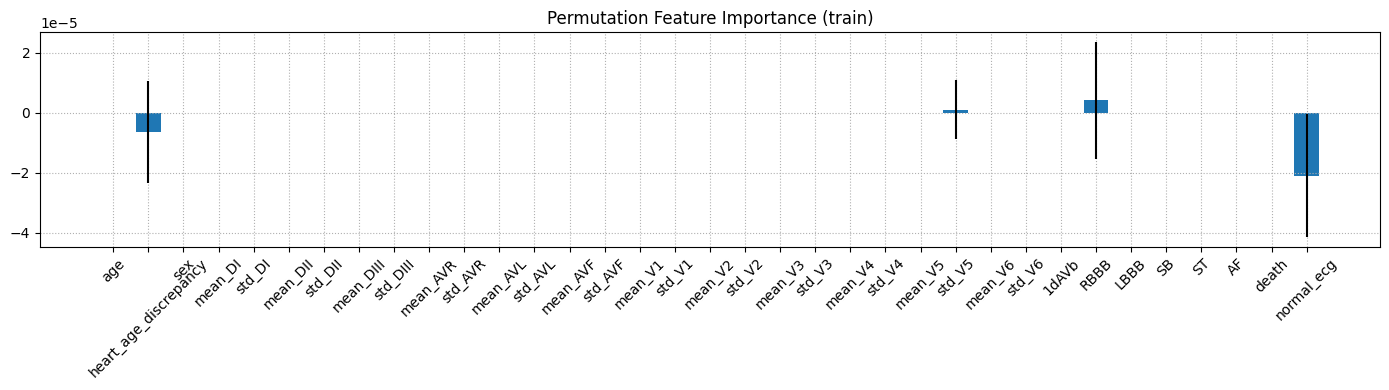

In [46]:
r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=42)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)')

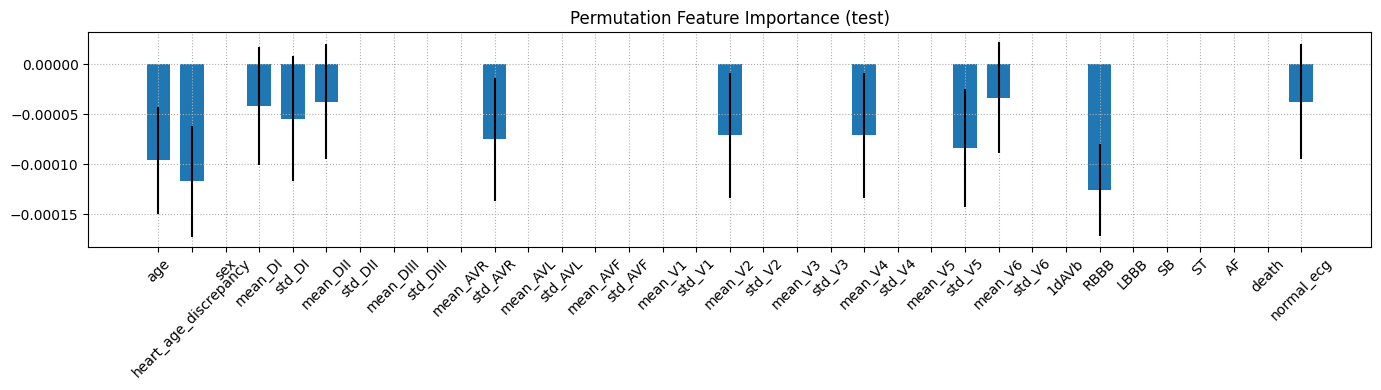

In [47]:
r_test = permutation_importance(xbm, X_test, y_test, n_repeats=30, random_state=42)
xbm_p_imp = pd.Series(index=X.columns, data=r_test.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_test.importances_std, title='Permutation Feature Importance (test)')

In [51]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 10), link='logit')
shap_values = explainer(X_test)

  0%|          | 0/7960 [00:00<?, ?it/s]

  1%|          | 57/7960 [00:17<40:10,  3.28it/s]


KeyboardInterrupt: 

In [53]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=42)
bfs.fit(X=X, y=y)

In [54]:
print('Confirmed important:', X.columns[bfs.ranking_ == 1].values)
print('Uncomfirmed:', X.columns[bfs.ranking_ == 2].values)
print('Confirmed unimportant:', X.columns[bfs.ranking_ > 2].values)

Confirmed important: ['age' 'heart_age_discrepancy' 'std_AVR' 'mean_AVF' 'mean_V2' 'mean_V4'
 'RBBB' 'normal_ecg']
Uncomfirmed: ['std_V5']
Confirmed unimportant: ['sex' 'mean_DI' 'std_DI' 'mean_DII' 'std_DII' 'mean_DIII' 'std_DIII'
 'mean_AVR' 'mean_AVL' 'std_AVL' 'std_AVF' 'mean_V1' 'std_V1' 'std_V2'
 'mean_V3' 'std_V3' 'std_V4' 'mean_V5' 'mean_V6' 'std_V6' '1dAVb' 'LBBB'
 'SB' 'ST' 'AF' 'death']
